# Comparaison des deux modèles utilisés
## Importation des bibliothèques

In [19]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


## Prétraitement des données 

In [12]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [13]:
post_flight_features = ['dep_delay', 'nas_delay', 'carrier_delay', 'late_aircraft_delay', 'taxi_out', 'taxi_in', 'weather_delay', 'air_time', 'actual_elapsed_time', 'arr_hour', 'arr_min', 'wheels_on_hour', 'wheels_on_min', 'wheels_off_hour', 'wheels_off_min', 'security_delay', 'diverted', 'cancelled']

df_preflight = df.drop(columns=post_flight_features)


In [14]:
# matrice des features
X = df_preflight.drop(columns=["arr_delay"], axis=1)
# variable cible -> celle que l'on veut prédire
# Transformation de la variable cible en binaire: 1 = delayed, 0 = not delayed
y = (df_preflight["arr_delay"]>0).astype(int)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Chargement des modèles et des features 

In [16]:
rf_model = joblib.load("../models/random_forest_model.pkl")
lightgbm_model = joblib.load("../models/lightgbm_model.pkl")

In [17]:
rf_features = joblib.load("../models/selected_features_rf.pkl")
lightgbm_features = joblib.load("../models/selected_features_lightgbm.pkl")

## Application des features propres à chaque modèle

In [18]:
X_test_rf = X_test[rf_features]
X_test_lgb = X_test[lightgbm_features]

## Faire les prédictions et calculer les métriques

In [21]:
# Random Forest
y_pred_rf = rf_model.predict(X_test_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

# LightGBM
y_pred_lgb = lightgbm_model.predict(X_test_lgb)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
prec_lgb = precision_score(y_test, y_pred_lgb)
rec_lgb = recall_score(y_test, y_pred_lgb)

## Résumé des resultats

In [22]:
results = pd.DataFrame({
    "Modèle" : ["Random Forest", "LightGBM"],
    "Accuracy" : [acc_rf, acc_lgb],
    "Précision" : [prec_rf, prec_lgb],
    "Recall" : [rec_rf, rec_lgb]
})
print(results)

          Modèle  Accuracy  Précision    Recall
0  Random Forest  0.785483   0.738095  0.324365
1       LightGBM  0.857259   0.866051  0.560538


## Visualisation des résultats

<Axes: title={'center': 'Comparaison des modèles'}, xlabel='Modèle'>

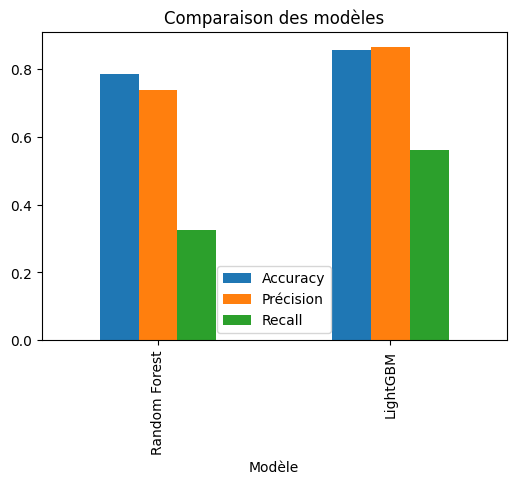

In [23]:
results.set_index("Modèle").plot(kind="bar", figsize=(6,4), title = "Comparaison des modèles")

## Conclusion

Le *recall* représente la capacité du modèle à détecter les vols réellement en retard.  
  Ici, il correspond donc aux vols retardés correctement prédits, et inversement aux *faux négatifs* (vols en retard prédit comme non retardés).  
Dans notre projet, *l’objectif principal est de prédire le plus de vols en retard possible*.  
Le Random Forest a un recall relativement faible (0.32), ce qui signifie qu’il *rate beaucoup de vols retardés*.  
Le LightGBM obtient un *recall plus élevé (0.56)* tout en ayant une précision et une accuracy supérieures, ce qui en fait *le modèle le plus adapté* à notre objectif.
On retiendra donc le modèle LightGBM pour la suite du projet